In [11]:

import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import KBinsDiscretizer
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from tqdm import tqdm 


In [12]:
# ---------------------------
# 1. Load preprocessed data and labels
# ---------------------------
import os

os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Momentum_vs_Value_trend']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_featureset = pd.read_csv("featureset.csv", parse_dates=['Date'])
#df_features = df_features.drop(['Momentum_vs_Quality_trend'],axis=1)
df_featureset = df_featureset.set_index('Date')

df_features = pd.read_csv("factor_relative_features.csv", parse_dates=['Date'])
#df_features = df_features.drop(['Momentum_vs_Quality_trend'],axis=1)
df_features = df_features.set_index('Date')

data = pd.concat([df_features,df_featureset,df_factor], axis=1, join='inner')
data = data.dropna()
feature_names = data.columns[:-1].tolist()


X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
feature_names = data.columns[:-1].tolist()


#X = pd.DataFrame(X, columns=feature_names)
print(X)


[[ 5.7201022e-02 -2.3082746e-02 -6.7875640e-03 ...  2.7586000e+00
  -3.7500000e-01 -2.0500000e-01]
 [-1.8293150e-03 -1.6422073e-02  3.9482039e-02 ...  2.6821000e+00
  -3.4500000e-01 -2.1500000e-01]
 [-3.0759428e-02 -1.7373082e-02  2.2312960e-03 ...  1.9729000e+00
  -3.6500000e-01 -2.9000000e-01]
 ...
 [ 2.4222832e-02  2.3806898e-02 -5.6951410e-03 ...  2.6904000e+00
  -7.5000000e-02 -2.0000000e-02]
 [-2.7417612e-02 -1.4404430e-02 -2.8555770e-03 ...  2.7082000e+00
   1.0000000e-02  3.0000000e-02]
 [ 3.9298159e-02 -1.1381881e-02  5.7281630e-03 ...  2.7630000e+00
   6.5000000e-02  8.5000000e-02]]


In [13]:
# ---------------------------
# 2. Compute Mutual Information between features and target
# ---------------------------
def compute_mi_scores(X, y, discrete_features='auto'):
    mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=42)
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    return mi_series

# mi_scores = compute_mi_scores(X, y)
# print(mi_scores.head())

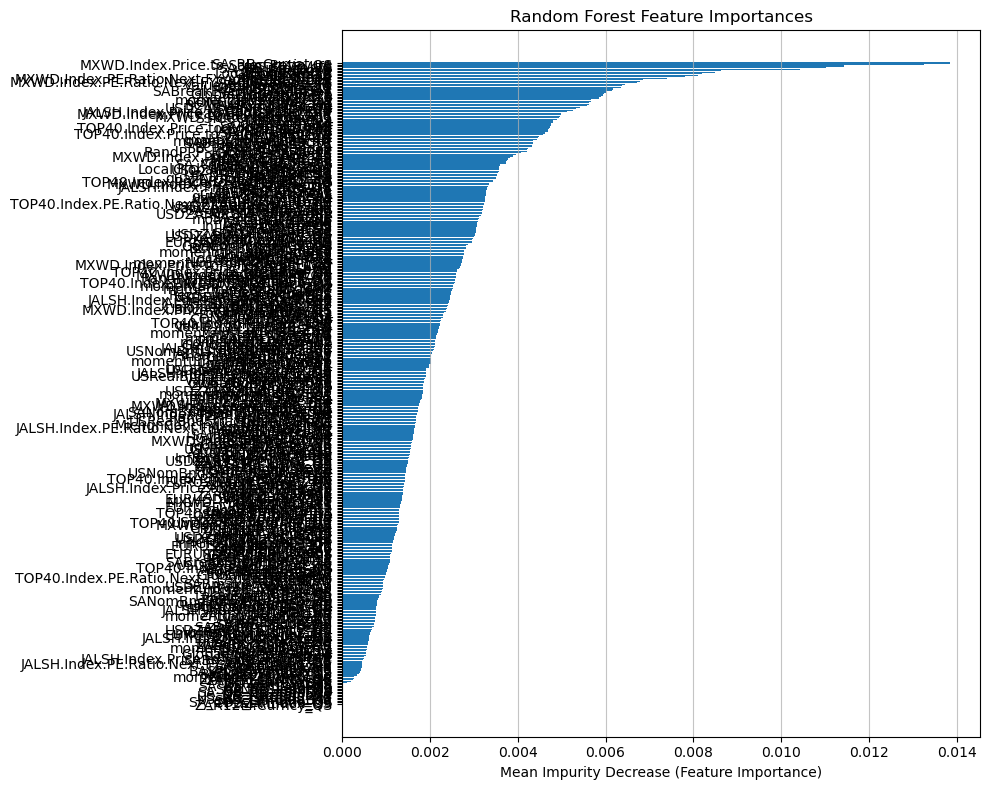


Top 5 most important features:
['US_NB_Slope' 'LEI.Totl_TS' 'GlobalBondSB' 'LocalBondsVol12'
 'LocalEquitySB' 'SA_RB_Slope' 'SA_RB_Slope_TS' 'USDZARVol6'
 'MXWD.Index.Price.to.Sales.Ratio_QS' 'SA_RB_Curvature']


In [14]:

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. Create a dataset
#X, y = make_classification(n_samples=1000, n_features=15, n_informative=5, n_redundant=5, n_repeated=0, random_state=42)
#feature_names = [f'Feature {i}' for i in range(X.shape[1])]

# 2. Train a Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Get Importances
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_imp_df = feature_imp_df.sort_values('importance', ascending=True) # Sort for horizontal plot

# 4. Visualize the Importances
plt.figure(figsize=(10, 8))
plt.barh(feature_imp_df['feature'], feature_imp_df['importance'])
plt.xlabel("Mean Impurity Decrease (Feature Importance)")
plt.title("Random Forest Feature Importances")
plt.grid(axis='x', alpha=0.75)
plt.tight_layout()
plt.show()

# 5. Select top 5 features
top_5_features = feature_imp_df.tail(10)['feature'].values
print("\nTop 5 most important features:")
print(top_5_features)

In [15]:
# ---------------------------
# 3. Compute pairwise normalized Mutual Information between features
# ---------------------------
def normalized_mi(x, y, n_bins=20):
    """Compute robust normalized MI between two continuous features."""
    kb = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    x_binned = kb.fit_transform(x.reshape(-1, 1))
    y_binned = kb.fit_transform(y.reshape(-1, 1))

    mi = mutual_info_score(x_binned[:, 0], y_binned[:, 0])
    h_x = mutual_info_score(x_binned[:, 0], x_binned[:, 0])
    h_y = mutual_info_score(y_binned[:, 0], y_binned[:, 0])

    # Guard against zero entropy
    denom = max(h_x, h_y)
    if denom == 0 or np.isnan(denom):
        return 0.0

    nmi = mi / denom
    return nmi

def mi_distance_matrix(X, n_bins=20):
    """Return MI-based distance matrix (1 - normalized_MI), robust to zero-entropy features."""
    n = X.shape[1]
    dist_matrix = np.zeros((n, n))
    columns = X.columns.to_list()

    print(f"Computing MI distance matrix for {n} features...")

    for i in tqdm(range(n)):
        for j in range(i + 1, n):
            try:
                nmi = normalized_mi(X.iloc[:, i].values, X.iloc[:, j].values, n_bins=n_bins)
                dist = 1 - nmi
            except Exception:
                dist = 1  # assign max distance if MI fails
            dist_matrix[i, j] = dist_matrix[j, i] = dist

    np.fill_diagonal(dist_matrix, 0)
    return pd.DataFrame(dist_matrix, index=columns, columns=columns)
X = pd.DataFrame(X, columns=feature_names)
D = mi_distance_matrix(X)
D.to_csv("MI_distance_matrix.csv")


Computing MI distance matrix for 422 features...


  0%|          | 0/422 [00:00<?, ?it/s]c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:262: UserWarning: Feature 0 is constant and will be replaced with 0.
  warnings.warn(
c:\Users\p528552\AppData\Local\

In [16]:

# ---------------------------
# 4. Hierarchical clustering using MI-based distances
# ---------------------------
def mi_hierarchical_clustering(D, mi_scores, n_clusters=None, threshold=None):
    """Perform hierarchical clustering using MI distances and select cluster representatives."""
    # Convert to condensed distance format
    condensed_D = squareform(D.values, checks=False)
    Z = linkage(condensed_D, method='average')

    # Plot dendrogram
    plt.figure(figsize=(12, 6))
    dendrogram(Z, labels=D.columns, leaf_rotation=90)
    plt.title("MI-Based Feature Clustering Dendrogram")
    plt.tight_layout()
    plt.show()

    # Cluster cutoff (either number of clusters or distance threshold)
    if threshold:
        clusters = fcluster(Z, t=threshold, criterion='distance')
    elif n_clusters:
        clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    else:
        raise ValueError("Specify either n_clusters or threshold.")

    cluster_df = pd.DataFrame({'feature': D.columns, 'cluster': clusters})
    cluster_representatives = []
    for c in cluster_df['cluster'].unique():
        members = cluster_df.loc[cluster_df['cluster'] == c, 'feature']
        # pick feature with highest MI-to-y within cluster
        rep = mi_scores[members].idxmax()
        cluster_representatives.append(rep)

    return cluster_representatives, cluster_df



In [17]:
# Example usage:


#selected_features, threshold = csfs_mi_pipeline(X, y)

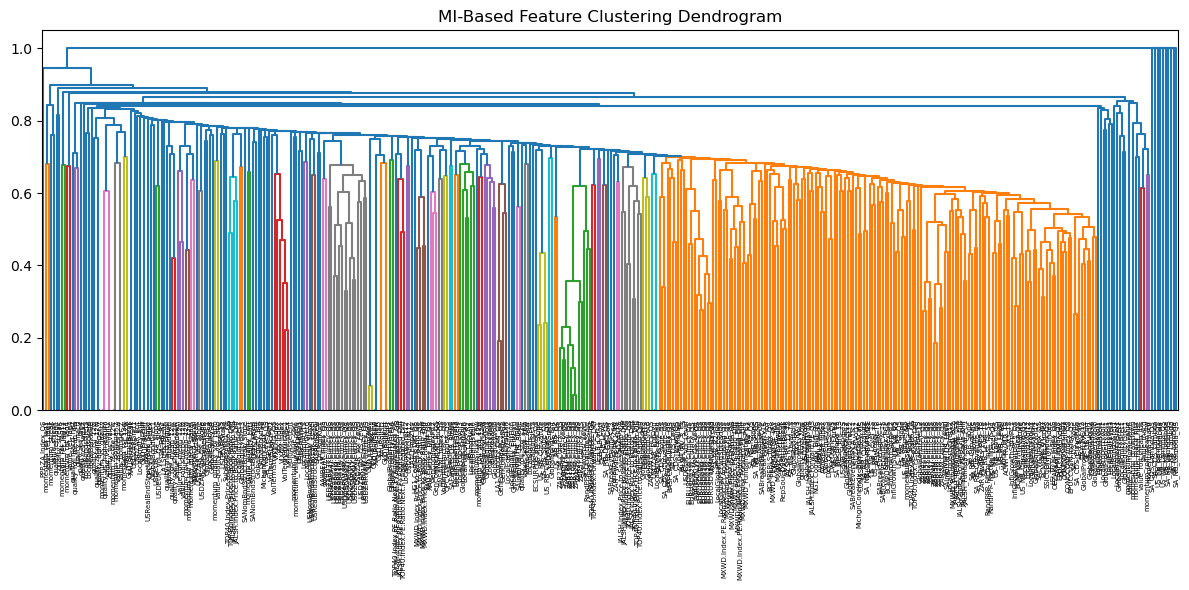

Selected Features: ['value_ret_lag1', 'momentum_ret_lag4', 'momentum_ret_lag12', 'momentum_macd', 'momentum_macd_signal', 'OEZAKLAF_YoY', 'momentum_streak', 'momentum_vs_value', 'momentum_vs_quality', 'momentum_zscore_12w', 'value_rsi_12w', 'value_macd_hist', 'momentum_drawdown', 'value_streak', 'quality_ret_lag1', 'quality_ret_lag4', 'quality_ret_lag12', 'quality_roll_mean_4w', 'quality_macd_signal', 'quality_streak', 'quality_zscore_12w', 'quality_rsi_12w', 'momentum_value_corr', 'momentum_value_vol_ratio', 'value_quality_corr', 'value_quality_vol_ratio', 'VIX1Y.Index', 'VolTermStructPC2', 'SA_PMI_TS', 'MichgnConcIndx_TS', 'SubIndex_PC1_TS', 'OPCVTPCR.Index', 'USDZARV9M.Curncy_QS', 'PPP.ZA.Index_QS', 'GLD_FracDiff', 'GLD_StructBreak', 'XAULempZiev', 'MXWD.Index.Price.to.Sales.Ratio_QS', 'LA1StructBreak', 'LA1LempZiev', 'LA1RollSkew', 'USNomBndStructBreak_Level', 'USNomBndStructBreak_Slope', 'USRealBndStructBreak_Slope', 'USDZARSB', 'SANomBndStructBreak_Slope', 'MOVEStructBreak', 'Loc

In [19]:
# Example workflow:
mi_scores = compute_mi_scores(X, y)
#D = mi_distance_matrix(X)
selected_features, clusters = mi_hierarchical_clustering(D, mi_scores, threshold=0.75)
print("Selected Features:", selected_features)

# ---------------------------
# 5. Save outputs
# ---------------------------
pd.Series(selected_features).to_csv("selected_features_MI_clustered.csv", index=True)
clusters.to_csv("MI_feature_clusters.csv", index=False)
